# Семинар · Блок 1 — Квартиры на продажу в Бишкеке

**Образцовый разбор.** Здесь мы проходим один срез данных — *объявления о продаже
квартир в Бишкеке* — и применяем к нему всё, что уже изучили: распределения и
гистограммы, среднее / мода / разброс, выбросы, нормирование (цена за м² и
z-стандартизация), объект как точку и поиск похожих (kNN).


## 0. Инструменты и данные

In [1]:
# В Google Colab сначала выполни:  !pip install -q datasets huggingface_hub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from huggingface_hub import hf_hub_download

sns.set_theme(style="whitegrid")            # сетка на всех графиках
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

/Users/simon/ds8_house_kg_proj/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Скачиваем таблицу объявлений `listings` (фото не трогаем).

In [2]:
path = hf_hub_download("aiacademy-kg/house_kg_full_dataset",
                       "data/listings.parquet", repo_type="dataset")
raw = pd.read_parquet(path)
print("строк:", len(raw), " колонок:", raw.shape[1])
raw.head(3)

строк: 25473  колонок: 72


,id,house_kg_id,source_url,pars_date,deal,type,region,city,address,title,description,latitude,longitude,price_usd_raw,price_kgs_raw,price_usd,price_kgs,price_period,views,posted_raw,posted_date,upped_raw,upped_date,seller_type,offer_type,declared_owner,seller_mismatch,author_user_id,author_name,author_url,author_ads_count,company_slug,company_url,complex_slug,complex_name,complex_url,rooms_n,area_m2,foto_ids,building_series,building,floor,area,heating,condition,bathroom,balcony,entrance_door,parking,furniture,flooring,misc,legal_documents,installment_available,mortgage_available,exchange_available,floors_total,land_area,sewerage,drinking_water,electricity,gas,ceiling_height,phone_line,internet,security,rent_period,object_type,location,utilities,rooms,irrigation_water
0,316de9ff-df25-4365-ae79-9a81fc93ee0c,21761286a3ffb6c37fce8-79783579,https://www.house.kg/details/21761286a3ffb6c37...,2026-07-12T19:54:01.968425+00:00,sale,apartment,batken,Кызыл-Кия,"Баткенская область, Кызыл-Кия, 60лет Киргизии 59","2-комн. кв., 5 м2",1 микрорайондон 2комнаталуу квартира сатылат\n...,40.2648,72.1262,$ 62 728,5 500 000 сом,62728.0,5500000.0,total,261.0,15 дней назад,2026-06-27T19:54:01.968425+00:00,NaN,NaN,owner,от собственника,True,False,412cfc103ad18ec0fd1d4b2298670,Пользователь,https://www.house.kg/user/412cfc103ad18ec0fd1d...,1,NaN,NaN,NaN,NaN,NaN,2.0,5.0,[30dd76d74f5547e3a89398a28b363e97],105 серия,монолитный,2 этаж из 5,5 м2,центральное,хорошее,раздельный,балкон,металлическая,паркинг,частично меблирована,ламинат,"неугловая, пластиковые окна, тихий двор",красная книга,есть,есть,обмен не предлагать,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6d645e9c-d521-410f-a42a-94e5248b892f,887746168d75880127373-90443346,https://www.house.kg/details/887746168d7588012...,2026-07-12T19:54:01.271332+00:00,sale,apartment,naryn,Кочкорка,"Нарынская область, Кочкорка, Сапар Алиева","3-комн. кв., 60 м2",Кочкор айылы\nС. Алиев көчөсүнөн\nэтаж үйдөн 3...,42.2127,75.7531,$ 45 000,3 945 600 сом,45000.0,3945600.0,total,4146.0,10 месяцев назад,2025-09-15T19:54:01.271332+00:00,2 месяца назад,2026-05-13T19:54:01.271332+00:00,owner,от собственника,True,False,fded1405-9a6e-11ea-af1d-308d99b29f08,А,https://www.house.kg/user/fded1405-9a6e-11ea-a...,1,NaN,NaN,NaN,NaN,NaN,3.0,60.0,"[0222717c30f648e3bfb220580336cf70, 953ae27ea87...",105 серия,монолитный,2 этаж из 2,60 м2,электрическое,хорошее,раздельный,балкон,NaN,паркинг,частично меблирована,дерево,"кладовка, тихий двор, удобно под бизнес",технический паспорт,NaN,есть,рассмотрю варианты,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,26d0a873-e048-4778-a23c-34ff1d36e4bf,29926026a4e12e5b8e658-74526515,https://www.house.kg/details/29926026a4e12e5b8...,2026-07-12T19:54:02.342130+00:00,sale,house,issyk_kul,с. Кош-Коль,"Иссык-Кульская область, с. Кош-Коль, с. Кош-кол","Дом, 5-комн., 152 м2",Продается 2 этажный коттедж 152м2\nИссык-Куль ...,42.5439,76.6154,$ 198 000,17 360 640 сом,198000.0,17360640.0,total,134.0,4 дня назад,2026-07-08T19:54:02.342130+00:00,7 часов назад,2026-07-12T12:54:02.342130+00:00,company,от агента,False,False,NaN,Моя Столица,NaN,41,moya-stolitsa,https://www.house.kg/moya-stolitsa,NaN,NaN,NaN,5.0,152.0,"[7a09277ce6f84b25b618c7b27b135c99, 2478b0601e4...",NaN,кирпичный,NaN,152 м2,электрическое,под самоотделку (псо),NaN,NaN,NaN,NaN,NaN,NaN,NaN,договор долевого участия,NaN,NaN,NaN,2,1 сотка,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Фокусируемся: Бишкек · продажа · квартиры

Одна строка — это **объявление** (не квартира: одну и ту же квартиру могут выложить
разные агентства — но это тема Блока 2). Сузимся до нашего среза.

In [3]:
work = raw[(raw.deal == "sale") &
           (raw.type == "apartment") &
           (raw.city == "Бишкек")].copy()
print("объявлений в срезе:", len(work))

объявлений в срезе: 12851


## 2. Чистка: лишние колонки и пропуски

В таблице 72 поля, большинство нам не нужны и во многих — сплошные пропуски
(поля для участков, коммуникаций, аренды…). Сначала посмотрим, **насколько заполнены**
колонки, и оставим только осмысленные для квартиры.

Оставляем компактный набор: идентификаторы, цена, площадь, комнаты, просмотры,
состояние/серия/этаж, координаты и текст объявления. Остальное — выкидываем.

In [4]:
work.info()

<class 'pandas.DataFrame'>
Index: 12851 entries, 3353 to 16556
Data columns (total 72 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     12851 non-null  str    
 1   house_kg_id            12851 non-null  str    
 2   source_url             12851 non-null  str    
 3   pars_date              12851 non-null  str    
 4   deal                   12851 non-null  str    
 5   type                   12851 non-null  str    
 6   region                 12851 non-null  str    
 7   city                   12851 non-null  str    
 8   address                12851 non-null  str    
 9   title                  12851 non-null  str    
 10  description            12297 non-null  str    
 11  latitude               12850 non-null  float64
 12  longitude              12850 non-null  float64
 13  price_usd_raw          12851 non-null  str    
 14  price_kgs_raw          12851 non-null  str    
 15  price_usd      

In [5]:
keep = ["id", "house_kg_id", "title", "address",
        "price_usd", "price_kgs", "area_m2", "rooms_n", "views",
        "condition", "building_series", "floor",
        "latitude", "longitude", "posted_date"]
work = work[keep]
work.head(3)

,id,house_kg_id,title,address,price_usd,price_kgs,area_m2,rooms_n,views,condition,building_series,floor,latitude,longitude,posted_date
3353,14a15af7-dc9d-4605-bb1c-e4a7af4706e0,82376366a52392ebae6e5-96989503,"1-комн. кв., 44 м2","Бишкек, Пишпек ж/м, ул. Льва Толстого - Крылова",73000.0,6400640.0,44.0,1.0,1434.0,евроремонт,элитка,7 этаж из 14,42.8636,74.5442,2026-07-11T20:25:54.720132+00:00
3354,d0f07c40-9c6b-4e7e-a9b5-30f68658148a,81630446a51c73b84cd20-75921552,"3-комн. кв., 103 м2","Бишкек, Магистраль, Аалы Токомбаева 21/4/Кутту...",198000.0,17360640.0,103.0,3.0,1480.0,евроремонт,элитка,5 этаж из 10,42.8171,74.6170,2026-07-10T20:25:55.249187+00:00
3355,cb7a2233-580f-49b4-bab6-185a8d256d7c,91674646a0b524b6db844-77587643,"2-комн. кв., 85.3 м2","Бишкек, Магистраль, ​Байтик Баатыра 4Б/3 / Южн...",104800.0,9188864.0,85.3,2.0,9862.0,под самоотделку (псо),элитка,11 этаж из 12,42.8184,74.6039,2026-05-13T20:25:56.226958+00:00


In [6]:
work.info()

<class 'pandas.DataFrame'>
Index: 12851 entries, 3353 to 16556
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               12851 non-null  str    
 1   house_kg_id      12851 non-null  str    
 2   title            12851 non-null  str    
 3   address          12851 non-null  str    
 4   price_usd        12851 non-null  float64
 5   price_kgs        12851 non-null  float64
 6   area_m2          12851 non-null  float64
 7   rooms_n          12776 non-null  float64
 8   views            12850 non-null  float64
 9   condition        11456 non-null  str    
 10  building_series  12850 non-null  str    
 11  floor            12846 non-null  str    
 12  latitude         12850 non-null  float64
 13  longitude        12850 non-null  float64
 14  posted_date      12850 non-null  str    
dtypes: float64(7), str(8)
memory usage: 4.6 MB


### 2.1 Пропуски в числе комнат — это не случайность

У части объявлений не распарсилось число комнат. Прежде чем просто их выкинуть —
посмотрим, **кто** эти объявления. Они не «обычные»: среди них аномально большие
площади (пентхаусы, «свободная планировка», ошибки ввода).

In [7]:
work.rooms_n.unique()

array([ 1.,  3.,  2.,  4.,  5., nan])

In [8]:
work.title.map(lambda i: i.split(', ')[0]).unique()

<ArrowStringArray>
['1-комн. кв.', '3-комн. кв.', '2-комн. кв.', '4-комн. кв.', '5-комн. кв.', '6 и более комнат кв.', 'свободная планировка кв.']
Length: 7, dtype: str

In [9]:
miss = work[work.rooms_n.isna()].copy()
miss["area_m2"] = pd.to_numeric(miss["area_m2"], errors="coerce")
print("объявлений без числа комнат:", len(miss))
print("их площадь: median = %.0f  max = %.0f м²"
      % (miss.area_m2.median(), miss.area_m2.max()))
print("\nпримеры (заголовок · площадь):")
print(miss.sort_values("area_m2", ascending=False)[["title", "area_m2"]].head(8).to_string(index=False))

объявлений без числа комнат: 75
их площадь: median = 213  max = 615 м²

примеры (заголовок · площадь):
                           title  area_m2
свободная планировка кв., 615 м2    615.0
    6 и более комнат кв., 571 м2    571.0
свободная планировка кв., 525 м2    525.0
    6 и более комнат кв., 524 м2    524.0
    6 и более комнат кв., 505 м2    505.0
    6 и более комнат кв., 450 м2    450.0
    6 и более комнат кв., 400 м2    400.0
    6 и более комнат кв., 400 м2    400.0


Вывод: пропуск в `rooms_n` часто маркирует **нетипичный** объект. На этом семинаре
мы честно их **отбрасываем** (не «додумываем» число комнат) — но теперь знаем, что
именно теряем. Заодно выкидываем строки без цены/площади.

In [10]:
work["price_usd"] = pd.to_numeric(work["price_usd"], errors="coerce")
work["area_m2"]   = pd.to_numeric(work["area_m2"],   errors="coerce")
work["views"]     = pd.to_numeric(work["views"],     errors="coerce")

before = len(work)
work = work.dropna(subset=["price_usd", "area_m2", "rooms_n"]).copy()
print(f"было {before} → стало {len(work)} (отброшено {before - len(work)})")

было 12851 → стало 12776 (отброшено 75)


## 3. Обзорные графики — сначала посмотреть на форму

Среднее и разброс — потом. Сначала глаза: как распределены цена, площадь и цена за м².

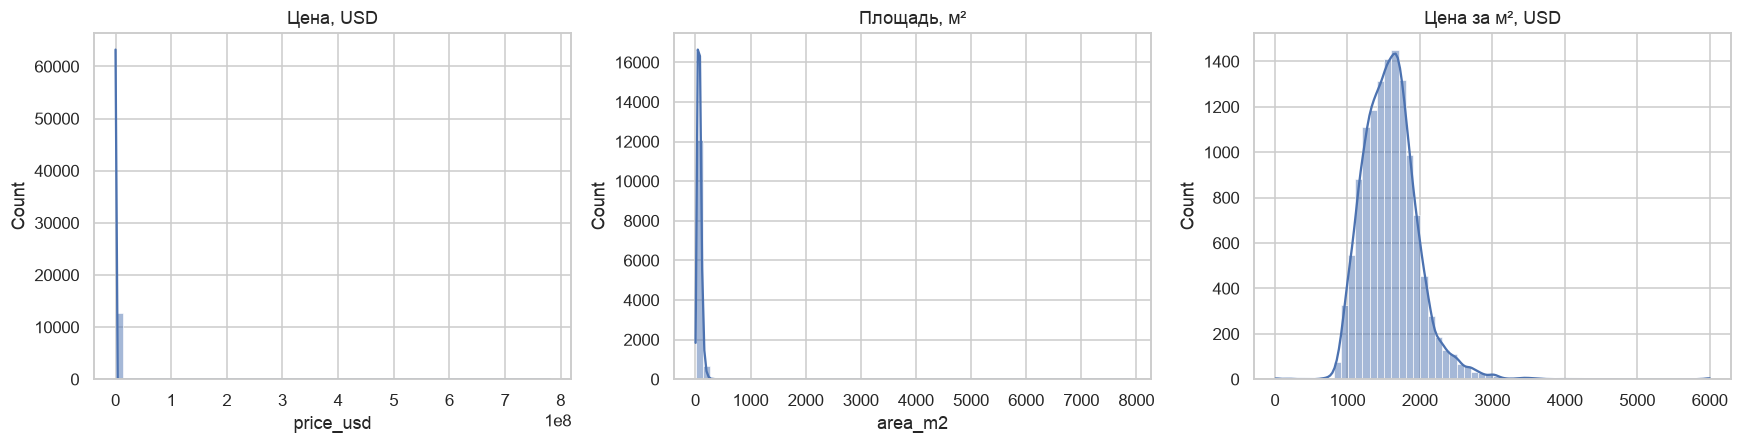

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
sns.histplot(work.price_usd, bins=60, kde=True, ax=ax[0]); ax[0].set_title("Цена, USD")
sns.histplot(work.area_m2,  bins=60, kde=True, ax=ax[1]); ax[1].set_title("Площадь, м²")
work_ppm2_preview = work.price_usd / work.area_m2
sns.histplot(work_ppm2_preview.clip(upper=6000), bins=60, kde=True, ax=ax[2]); ax[2].set_title("Цена за м², USD")
fig.tight_layout(); plt.show()

Все три — **право-скошенные** с длинным хвостом: основная масса слева, редкие
огромные значения тянут хвост вправо. По такой картинке уже видно, что среднее будет
завышено относительно «типичного» жилья.

In [12]:
work.price_usd.describe()

count    1.277600e+04
mean     1.784635e+05
std      6.900101e+06
min      2.300000e+04
25%      7.384800e+04
50%      9.700000e+04
75%      1.380000e+05
max      7.800017e+08
Name: price_usd, dtype: float64

In [13]:
work.price_usd.mean(), work.price_usd.std(), work.price_usd.max()

(np.float64(178463.4696305573),
 np.float64(6900100.5177568905),
 np.float64(780001696.0))

In [14]:
work.columns

Index(['id', 'house_kg_id', 'title', 'address', 'price_usd', 'price_kgs', 'area_m2', 'rooms_n', 'views', 'condition', 'building_series', 'floor', 'latitude',
       'longitude', 'posted_date'],
      dtype='str')

In [15]:
work = work[work.price_usd < 5e7]

In [16]:
work.price_usd.mean(), work.price_usd.std(), work.price_usd.max()

(np.float64(117420.55514677103),
 np.float64(70557.86007708608),
 np.float64(1500000.0))

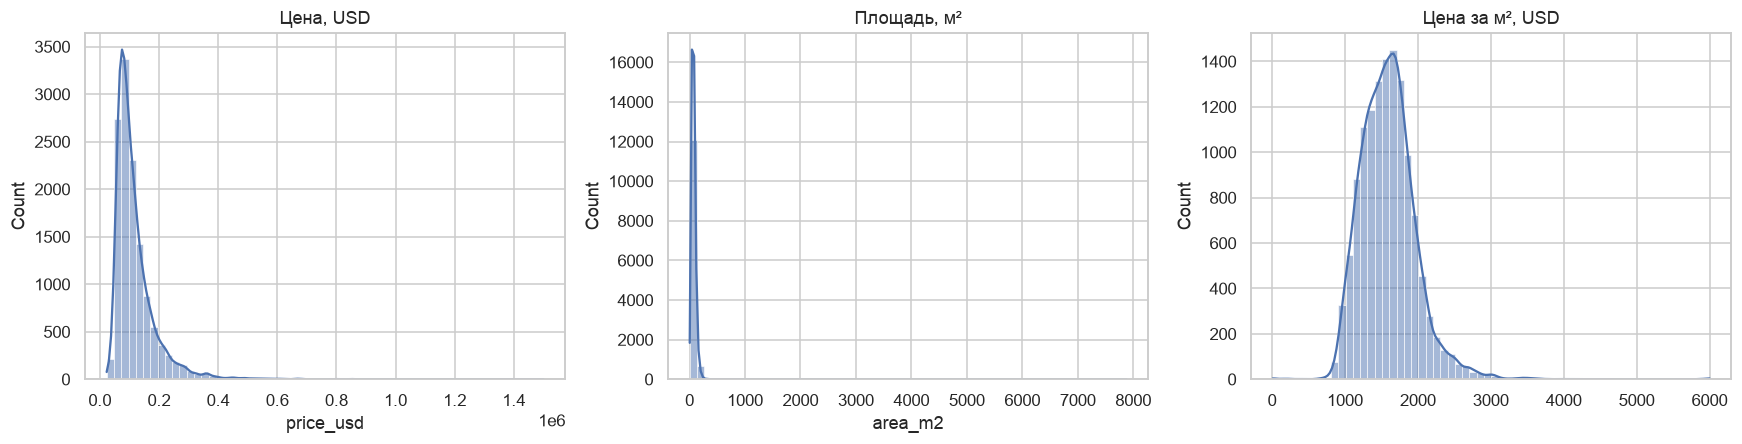

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
sns.histplot(work.price_usd, bins=60, kde=True, ax=ax[0]); ax[0].set_title("Цена, USD")
sns.histplot(work.area_m2,  bins=60, kde=True, ax=ax[1]); ax[1].set_title("Площадь, м²")
work_ppm2_preview = work.price_usd / work.area_m2
sns.histplot(work_ppm2_preview.clip(upper=6000), bins=60, kde=True, ax=ax[2]); ax[2].set_title("Цена за м², USD")
fig.tight_layout(); plt.show()

In [18]:
work_ppm2_preview = work.price_usd / work.area_m2
work_ppm2_preview

3353     1659.090909
3354     1922.330097
3355     1228.604924
3356     1728.110599
3357     1627.450980
            ...     
16551    1237.113402
16552    2285.714286
16553    1272.166538
16554    1753.246753
16556    1046.875000
Length: 12775, dtype: float64

In [19]:
work_ppm2_preview.describe()

count    12775.000000
mean      1598.694338
std        462.190612
min          9.900990
25%       1328.430312
50%       1573.720000
75%       1801.431538
max      20428.571429
dtype: float64

Cut off by 2 std

In [20]:
right = work_ppm2_preview.mean() + 2 * work_ppm2_preview.std()
left = work_ppm2_preview.mean() - 2 * work_ppm2_preview.std()

In [21]:
mask = (work_ppm2_preview > left) & (work_ppm2_preview < right)


In [22]:
work_ppm2_preview = work_ppm2_preview[mask]

<Axes: ylabel='Density'>

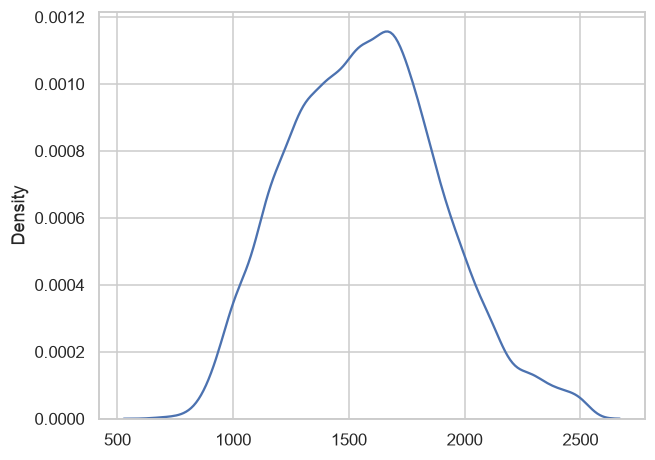

In [23]:
sns.kdeplot(work_ppm2_preview)

In [24]:
work = work[mask]

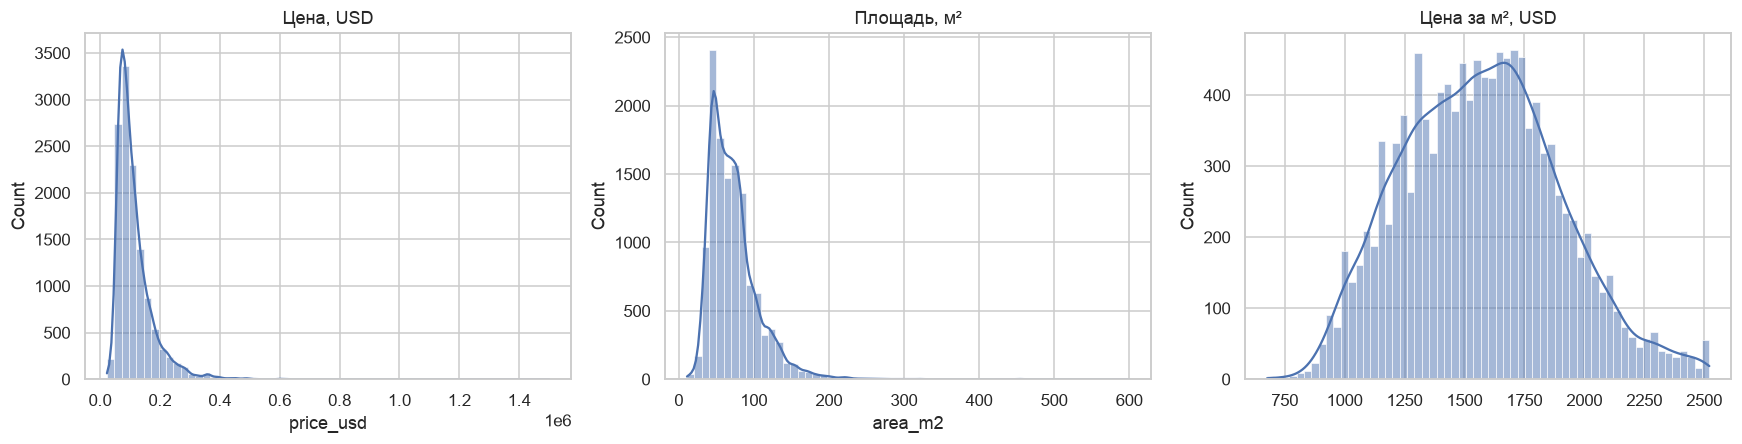

In [25]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
sns.histplot(work.price_usd, bins=60, kde=True, ax=ax[0]); ax[0].set_title("Цена, USD")
sns.histplot(work.area_m2,  bins=60, kde=True, ax=ax[1]); ax[1].set_title("Площадь, м²")
sns.histplot(work_ppm2_preview.clip(upper=6000), bins=60, kde=True, ax=ax[2]); ax[2].set_title("Цена за м², USD")
fig.tight_layout(); plt.show()

In [26]:
pr_mask = work.price_usd < work.price_usd.mean() + 2.5 * work.price_usd.std()

In [27]:
work = work[pr_mask]

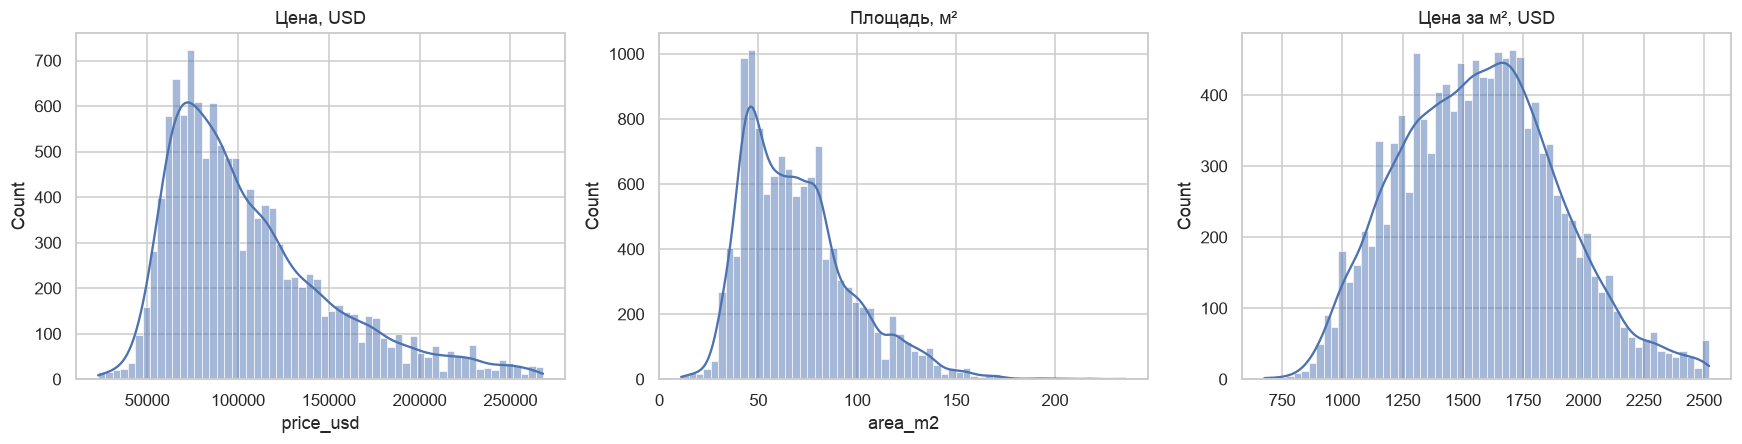

In [28]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
sns.histplot(work.price_usd, bins=60, kde=True, ax=ax[0]); ax[0].set_title("Цена, USD")
sns.histplot(work.area_m2,  bins=60, kde=True, ax=ax[1]); ax[1].set_title("Площадь, м²")
sns.histplot(work_ppm2_preview.clip(upper=6000), bins=60, kde=True, ax=ax[2]); ax[2].set_title("Цена за м², USD")
fig.tight_layout(); plt.show()

In [29]:
work.price_usd.describe()

count     12157.000000
mean     106923.575471
std       45860.434452
min       23000.000000
25%       73000.000000
50%       94902.000000
75%      129659.000000
max      268000.000000
Name: price_usd, dtype: float64

In [30]:
work_ppm2_preview.describe()

count    12521.000000
mean      1570.836853
std        327.840692
min        676.470588
25%       1323.076923
50%       1565.762004
75%       1789.447368
max       2521.320908
dtype: float64

# Coords

<Axes: xlabel='longitude', ylabel='latitude'>

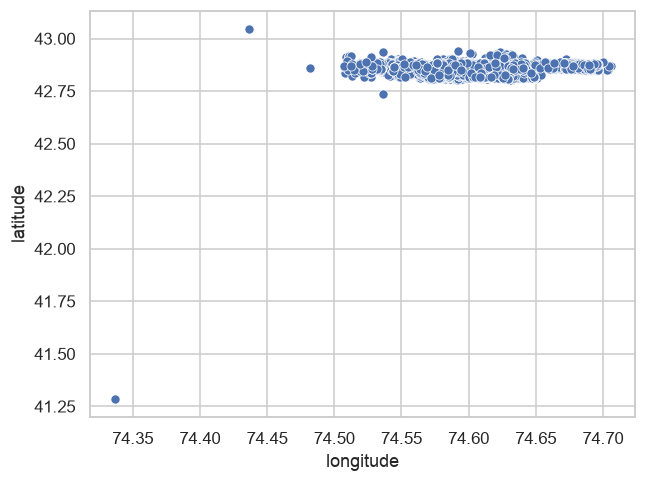

In [31]:
sns.scatterplot(data=work, y='latitude', x='longitude')

In [32]:
work = work[(work.longitude > 74.5) & (work.latitude > 42.75)]

In [33]:
work.columns

Index(['id', 'house_kg_id', 'title', 'address', 'price_usd', 'price_kgs', 'area_m2', 'rooms_n', 'views', 'condition', 'building_series', 'floor', 'latitude',
       'longitude', 'posted_date'],
      dtype='str')

<Axes: xlabel='longitude', ylabel='latitude'>

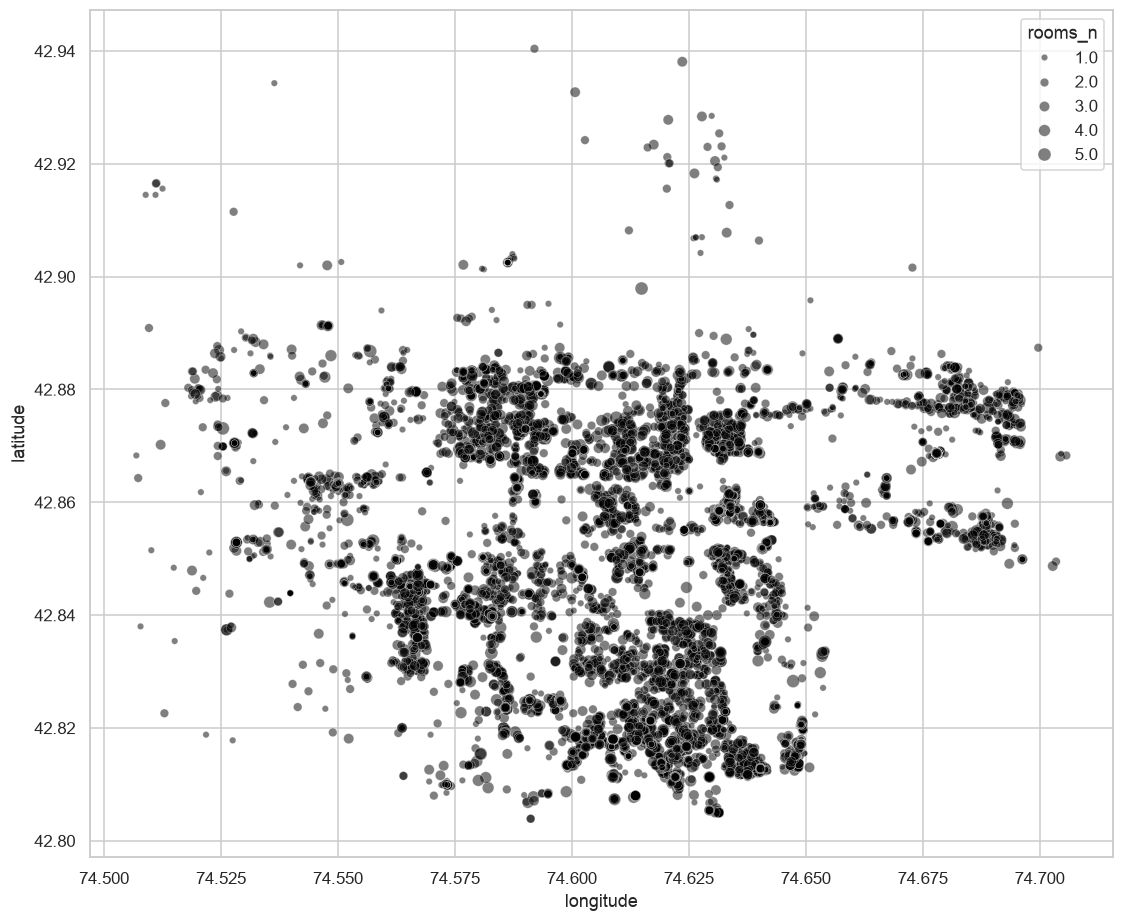

In [34]:
plt.subplots(figsize=(12, 10))
sns.scatterplot(data=work, y='latitude', x='longitude', color='black', alpha=.5, size='rooms_n')

<Axes: xlabel='area_m2', ylabel='Density'>

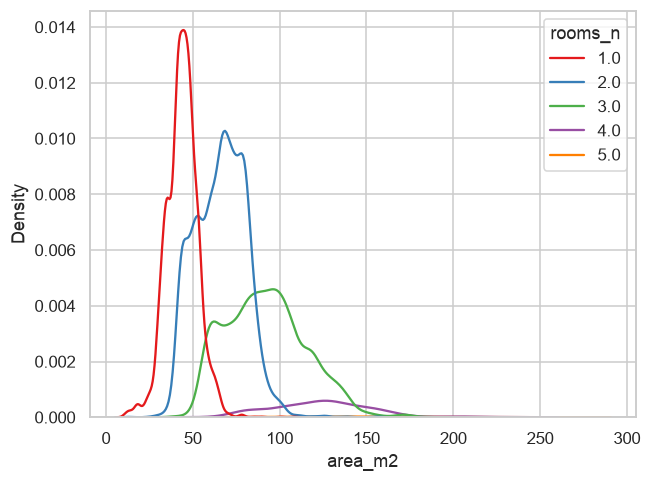

In [35]:
sns.kdeplot(data=work, x='area_m2', hue='rooms_n', palette='Set1')

In [36]:
work

,id,house_kg_id,title,address,price_usd,price_kgs,area_m2,rooms_n,views,condition,building_series,floor,latitude,longitude,posted_date
3353,14a15af7-dc9d-4605-bb1c-e4a7af4706e0,82376366a52392ebae6e5-96989503,"1-комн. кв., 44 м2","Бишкек, Пишпек ж/м, ул. Льва Толстого - Крылова",73000.0,6400640.0,44.00,1.0,1434.0,евроремонт,элитка,7 этаж из 14,42.8636,74.5442,2026-07-11T20:25:54.720132+00:00
3354,d0f07c40-9c6b-4e7e-a9b5-30f68658148a,81630446a51c73b84cd20-75921552,"3-комн. кв., 103 м2","Бишкек, Магистраль, Аалы Токомбаева 21/4/Кутту...",198000.0,17360640.0,103.00,3.0,1480.0,евроремонт,элитка,5 этаж из 10,42.8171,74.6170,2026-07-10T20:25:55.249187+00:00
3355,cb7a2233-580f-49b4-bab6-185a8d256d7c,91674646a0b524b6db844-77587643,"2-комн. кв., 85.3 м2","Бишкек, Магистраль, ​Байтик Баатыра 4Б/3 / Южн...",104800.0,9188864.0,85.30,2.0,9862.0,под самоотделку (псо),элитка,11 этаж из 12,42.8184,74.6039,2026-05-13T20:25:56.226958+00:00
3357,332c44aa-e1a1-427c-92e3-65ef80f326f7,51086856a512cc3c2fc25-16315865,"2-комн. кв., 51 м2","Бишкек, Кулатова- Матросова, Льва Толстого 6К/...",83000.0,7277440.0,51.00,2.0,525.0,евроремонт,индивид. планировка,13 этаж из 15,42.8632,74.6203,2026-07-10T20:25:55.934121+00:00
3358,af37b0b3-cb16-4cba-bd9f-3a23a2e0ca0b,325998569e36bc0effa64-68323226,"2-комн. кв., 41 м2","Бишкек, Парк Ататюрк",76000.0,6663680.0,41.00,2.0,2963.0,хорошее,104 серия,4 этаж из 4,42.8459,74.5973,2026-04-13T20:25:57.387163+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16551,df8ddac6-9f40-417e-826b-eed3dd029d01,88347856a0a97aaacd8f4-33063456,"3-комн. кв., 97 м2","Бишкек, Магистраль, Байтик Баатыра/Токомбаева",120000.0,10521600.0,97.00,3.0,784.0,под самоотделку (псо),элитка,11 этаж из 16,42.8180,74.6088,2026-05-13T22:33:30.082725+00:00
16552,d4b75ce5-673e-45d2-b2e3-6a056276c559,8355266a0a7d696f9f30-25283994,"1-комн. кв., 35 м2","Бишкек, Магистраль, Аалы Токомбаева 21/4 / Кут...",80000.0,7014400.0,35.00,1.0,947.0,евроремонт,элитка,4 этаж из 12,42.8171,74.6170,2026-05-13T22:33:29.874282+00:00
16553,4624cf36-6ca0-4984-934b-8927d3e5bb5a,58869166a0a27033798f4-16595003,"2-комн. кв., 77.82 м2","Бишкек, Шлагбаум, ул. Московская/ ул. Фучика",99000.0,8680320.0,77.82,2.0,1356.0,под самоотделку (псо),элитка,6 этаж из 10,42.8740,74.5609,2026-05-13T22:33:31.212622+00:00
16554,10d9338f-d9a2-4f50-9ab7-da5e1f1776e2,78479046a0a9e5f9ded03-21476553,"2-комн. кв., 77 м2","Бишкек, Магистраль, ​Байтик Баатыра 4Б/3/Южная...",135000.0,11836800.0,77.00,2.0,485.0,евроремонт,элитка,12 этаж из 13,42.8181,74.6044,2026-05-13T22:33:29.595722+00:00


### 3.1 Спойлер (просто пусть будет): логарифм выпрямляет хвост

Забегая вперёд — если взять **логарифм** цены и площади, тяжёлый хвост превращается в
аккуратный симметричный горб. Пока просто полюбуемся; зачем это — узнаем позже.

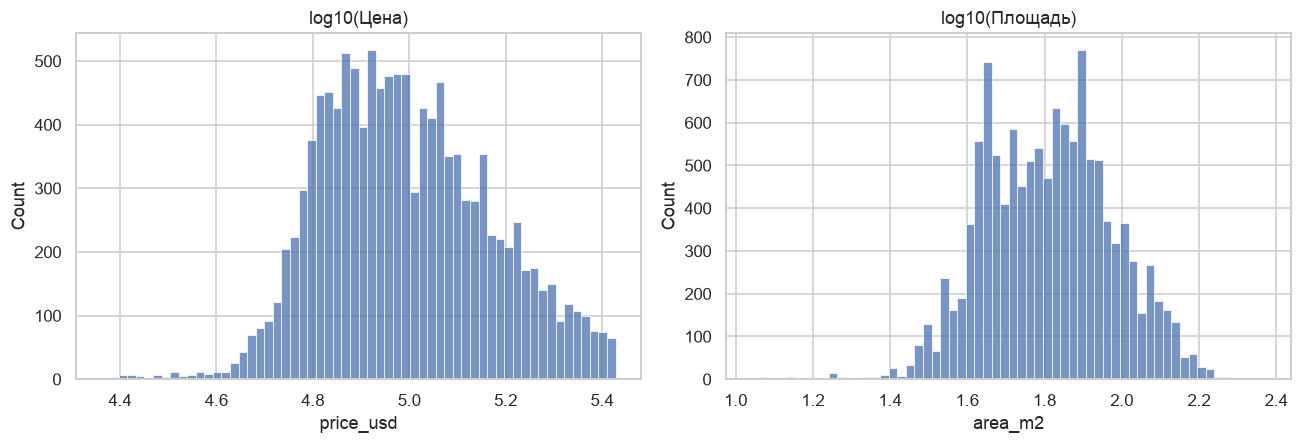

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
sns.histplot(np.log10(work.price_usd), bins=60, ax=ax[0]); ax[0].set_title("log10(Цена)")
sns.histplot(np.log10(work.area_m2),  bins=60, ax=ax[1]); ax[1].set_title("log10(Площадь)")
fig.tight_layout(); plt.show()

### 3.2 Комнаты и структура облака

Число комнат — дискретное. А scatter «площадь × цена», раскрашенный по комнатам,
показывает, что общее облако — это **склеенные группы** (однушки, двушки, трёшки…).

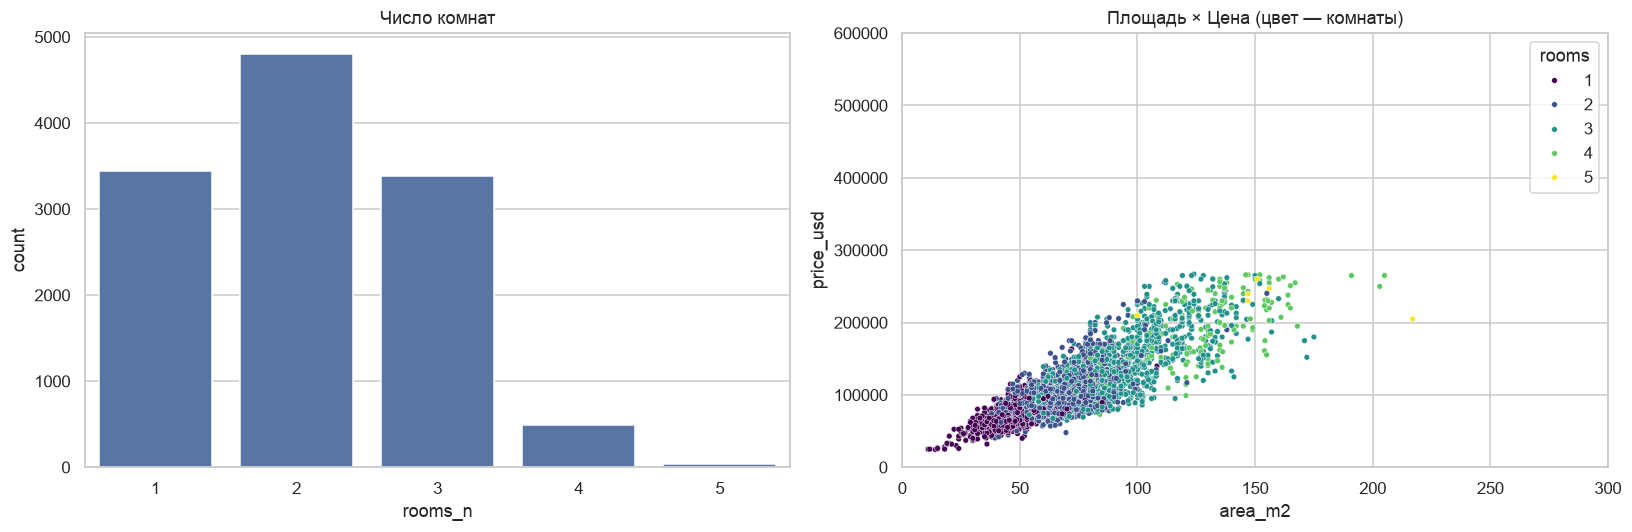

In [38]:
samp = work.sample(min(4000, len(work)), random_state=0).copy()
samp["rooms"] = samp.rooms_n.astype(int)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(x=work.rooms_n.astype(int), ax=ax[0]); ax[0].set_title("Число комнат")
sns.scatterplot(data=samp, x="area_m2", y="price_usd", hue="rooms",
                palette="viridis", s=14, ax=ax[1])
ax[1].set_title("Площадь × Цена (цвет — комнаты)")
ax[1].set_xlim(0, 300); ax[1].set_ylim(0, 600000)
fig.tight_layout(); plt.show()

In [39]:
work

,id,house_kg_id,title,address,price_usd,price_kgs,area_m2,rooms_n,views,condition,building_series,floor,latitude,longitude,posted_date
3353,14a15af7-dc9d-4605-bb1c-e4a7af4706e0,82376366a52392ebae6e5-96989503,"1-комн. кв., 44 м2","Бишкек, Пишпек ж/м, ул. Льва Толстого - Крылова",73000.0,6400640.0,44.00,1.0,1434.0,евроремонт,элитка,7 этаж из 14,42.8636,74.5442,2026-07-11T20:25:54.720132+00:00
3354,d0f07c40-9c6b-4e7e-a9b5-30f68658148a,81630446a51c73b84cd20-75921552,"3-комн. кв., 103 м2","Бишкек, Магистраль, Аалы Токомбаева 21/4/Кутту...",198000.0,17360640.0,103.00,3.0,1480.0,евроремонт,элитка,5 этаж из 10,42.8171,74.6170,2026-07-10T20:25:55.249187+00:00
3355,cb7a2233-580f-49b4-bab6-185a8d256d7c,91674646a0b524b6db844-77587643,"2-комн. кв., 85.3 м2","Бишкек, Магистраль, ​Байтик Баатыра 4Б/3 / Южн...",104800.0,9188864.0,85.30,2.0,9862.0,под самоотделку (псо),элитка,11 этаж из 12,42.8184,74.6039,2026-05-13T20:25:56.226958+00:00
3357,332c44aa-e1a1-427c-92e3-65ef80f326f7,51086856a512cc3c2fc25-16315865,"2-комн. кв., 51 м2","Бишкек, Кулатова- Матросова, Льва Толстого 6К/...",83000.0,7277440.0,51.00,2.0,525.0,евроремонт,индивид. планировка,13 этаж из 15,42.8632,74.6203,2026-07-10T20:25:55.934121+00:00
3358,af37b0b3-cb16-4cba-bd9f-3a23a2e0ca0b,325998569e36bc0effa64-68323226,"2-комн. кв., 41 м2","Бишкек, Парк Ататюрк",76000.0,6663680.0,41.00,2.0,2963.0,хорошее,104 серия,4 этаж из 4,42.8459,74.5973,2026-04-13T20:25:57.387163+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16551,df8ddac6-9f40-417e-826b-eed3dd029d01,88347856a0a97aaacd8f4-33063456,"3-комн. кв., 97 м2","Бишкек, Магистраль, Байтик Баатыра/Токомбаева",120000.0,10521600.0,97.00,3.0,784.0,под самоотделку (псо),элитка,11 этаж из 16,42.8180,74.6088,2026-05-13T22:33:30.082725+00:00
16552,d4b75ce5-673e-45d2-b2e3-6a056276c559,8355266a0a7d696f9f30-25283994,"1-комн. кв., 35 м2","Бишкек, Магистраль, Аалы Токомбаева 21/4 / Кут...",80000.0,7014400.0,35.00,1.0,947.0,евроремонт,элитка,4 этаж из 12,42.8171,74.6170,2026-05-13T22:33:29.874282+00:00
16553,4624cf36-6ca0-4984-934b-8927d3e5bb5a,58869166a0a27033798f4-16595003,"2-комн. кв., 77.82 м2","Бишкек, Шлагбаум, ул. Московская/ ул. Фучика",99000.0,8680320.0,77.82,2.0,1356.0,под самоотделку (псо),элитка,6 этаж из 10,42.8740,74.5609,2026-05-13T22:33:31.212622+00:00
16554,10d9338f-d9a2-4f50-9ab7-da5e1f1776e2,78479046a0a9e5f9ded03-21476553,"2-комн. кв., 77 м2","Бишкек, Магистраль, ​Байтик Баатыра 4Б/3/Южная...",135000.0,11836800.0,77.00,2.0,485.0,евроремонт,элитка,12 этаж из 13,42.8181,74.6044,2026-05-13T22:33:29.595722+00:00


KNN

In [40]:
work = work.reset_index(drop=True)

In [46]:
X = work[['price_usd',	'area_m2', 'rooms_n']].to_numpy()
X

array([[7.300e+04, 4.400e+01, 1.000e+00],
       [1.980e+05, 1.030e+02, 3.000e+00],
       [1.048e+05, 8.530e+01, 2.000e+00],
       ...,
       [9.900e+04, 7.782e+01, 2.000e+00],
       [1.350e+05, 7.700e+01, 2.000e+00],
       [6.700e+04, 6.400e+01, 1.000e+00]], shape=(12153, 3))

In [85]:
anchor_ind = 2342
anchor = X[anchor_ind]
work.iloc[anchor_ind]

id                 27b3cf7d-200e-4d17-9cdf-d03e15d882ed
house_kg_id              1754059693141ecaf6a28-22387371
title                                3-комн. кв., 91 м2
address             Бишкек, Магистраль, Аалы Токомбаева
price_usd                                      118000.0
price_kgs                                    10346240.0
area_m2                                            91.0
rooms_n                                             3.0
views                                            2370.0
condition                         под самоотделку (псо)
building_series                                  элитка
floor                                     11 этаж из 12
latitude                                        42.8177
longitude                                        74.622
posted_date            2025-12-14T20:48:48.852336+00:00
Name: 2342, dtype: object

In [86]:
anchor

array([1.18e+05, 9.10e+01, 3.00e+00])

# KNN Euclidean


In [87]:
eucl_dist = np.linalg.norm(X - anchor, axis=1)

In [88]:
top_10_ind = np.argsort(eucl_dist)[:11]
top_10_ind

array([ 2342,  9626,  5182,   240,   205, 10420, 12144, 10971, 11098,
         220,  9492])

In [89]:
top_10 = work.iloc[top_10_ind]

In [90]:
top_10.describe()

,price_usd,price_kgs,area_m2,rooms_n,views,latitude,longitude
count,11.0,11.0,11.000000,11.000000,11.000000,11.000000,11.000000
mean,118000.0,10346240.0,85.000000,2.545455,1174.454545,42.838782,74.606864
std,0.0,0.0,2.932576,0.687552,888.971806,0.019438,0.028761
min,118000.0,10346240.0,82.000000,2.000000,338.000000,42.817700,74.564800
25%,118000.0,10346240.0,82.500000,2.000000,565.000000,42.824700,74.576450
50%,118000.0,10346240.0,85.000000,2.000000,897.000000,42.831800,74.613900
75%,118000.0,10346240.0,86.500000,3.000000,1426.500000,42.851150,74.629000
max,118000.0,10346240.0,91.000000,4.000000,3201.000000,42.871100,74.643800


Проблема - цена задавила все остальное!

$$z = \frac{x-\overline{x}}{\sigma}$$

In [91]:
glob_mean = X.mean(axis=0)
glob_std = X.std(axis=0)

In [92]:
X_zero = (X - glob_mean) / glob_std

In [93]:
anchor_zero = (anchor - glob_mean) / glob_std

In [94]:
eucl_dist_zero = np.linalg.norm(X_zero - anchor_zero, axis=1)
top_10_ind_zero = np.argsort(eucl_dist_zero)[:11]
top_10_ind_zero

array([ 2342,  2512,   803,  7703,  3844,  2691,  2988,  9316,  8680,
       12008,  6942])

In [95]:
top_10_zero = work.iloc[top_10_ind_zero]
top_10_zero.describe()

,price_usd,price_kgs,area_m2,rooms_n,views,latitude,longitude
count,11.000000,1.100000e+01,11.000000,11.0,11.000000,11.000000,11.000000
mean,118381.818182,1.037972e+07,90.636364,3.0,1710.545455,42.835718,74.599918
std,1236.784688,1.084413e+05,0.809040,0.0,2153.672973,0.026029,0.036303
min,117000.000000,1.025856e+07,90.000000,3.0,238.000000,42.809900,74.544200
25%,117250.000000,1.028048e+07,90.000000,3.0,434.500000,42.817700,74.564800
50%,118000.000000,1.034624e+07,90.000000,3.0,896.000000,42.819900,74.613700
75%,119500.000000,1.047776e+07,91.000000,3.0,2141.000000,42.863000,74.622000
max,120000.000000,1.052160e+07,92.000000,3.0,7679.000000,42.880300,74.643300


In [96]:
top_10_zero

,id,house_kg_id,title,address,price_usd,price_kgs,area_m2,rooms_n,views,condition,building_series,floor,latitude,longitude,posted_date
2342,27b3cf7d-200e-4d17-9cdf-d03e15d882ed,1754059693141ecaf6a28-22387371,"3-комн. кв., 91 м2","Бишкек, Магистраль, Аалы Токомбаева",118000.0,10346240.0,91.0,3.0,2370.0,под самоотделку (псо),элитка,11 этаж из 12,42.8177,74.6220,2025-12-14T20:48:48.852336+00:00
2512,46e7fa84-3aa0-4f3e-b273-6a0d496796de,91367368f0832b389e83-53261255,"3-комн. кв., 91 м2","Бишкек, Магистраль, Аалы Токомбаева",117900.0,10337472.0,91.0,3.0,896.0,под самоотделку (псо),элитка,11 этаж из 12,42.8177,74.6220,2025-10-15T20:50:24.788747+00:00
803,34fa99be-fcbd-4465-af5a-2cf2d42b91f4,47462246a2a46c552da48-60077327,"3-комн. кв., 91 м2","Бишкек, Пишпек ж/м, Алыбаева 7 / Термечикова (...",117500.0,10302400.0,91.0,3.0,446.0,евроремонт,элитка,4 этаж из 14,42.8624,74.5520,2026-06-12T20:33:44.350708+00:00
7703,03dbd34f-6d12-4ddd-8a89-0ae2dc5b4052,25026446a2155ccda7688-56777935,"3-комн. кв., 90 м2","Бишкек, Магистраль, Арстанбека Дуйшеева 9",118800.0,10416384.0,90.0,3.0,423.0,под самоотделку (псо),элитка,4 этаж из 15,42.8199,74.6137,2026-06-12T21:49:24.804220+00:00
3844,3261a13a-cd57-44af-8013-099b30778e44,2874046a3a020e3ce5b1-14034623,"3-комн. кв., 92 м2","Бишкек, Магистраль, ул. Куттубаева, 15",119000.0,10433920.0,92.0,3.0,281.0,евроремонт,элитка,8 этаж из 14,42.8130,74.6193,2026-06-22T21:03:35.412997+00:00
2691,c528cfc7-a4e5-4270-b23a-7229a9d40680,18689406a2aa1fa643c69-42110059,"3-комн. кв., 90 м2","Бишкек, Магистраль, Арстанбека Дуйшеева 9",117000.0,10258560.0,90.0,3.0,467.0,под самоотделку (псо),элитка,4 этаж из 15,42.8199,74.6137,2026-06-12T20:52:12.990668+00:00
2988,55e2d46b-9943-4d1a-b416-b373bfb8d90e,35319968fcdf88a72a87-62944967,"3-комн. кв., 90 м2","Бишкек, Чуй - Алматинка",117000.0,10258560.0,90.0,3.0,2484.0,евроремонт,элитка,8 этаж из 9,42.8803,74.6393,2025-10-15T20:55:04.881717+00:00
9316,c2d9e4da-f4c4-4550-841e-de5943655662,76574216a1d435d87fbb0-31263147,"3-комн. кв., 90 м2","Бишкек, Ынтымак ж/м, Магистральная/Курултай",117000.0,10258560.0,90.0,3.0,1912.0,евроремонт,элитка,8 этаж из 9,42.8099,74.5734,2026-06-12T22:04:45.206211+00:00
8680,60c28e04-9eb5-43c7-a8b8-1f92a75ec99a,81167076a3b81be8c8a94-21269900,"3-комн. кв., 92 м2","Бишкек, с. Кок-Джар",120000.0,10521600.0,92.0,3.0,238.0,среднее,индивид. планировка,2 этаж из 4,42.8240,74.6433,2026-06-23T21:58:43.348182+00:00
12008,4f24760a-3b97-4bdb-80c3-62d49ac1282f,137374666be1ad7813335-88815612,"3-комн. кв., 90 м2","Бишкек, Ипподром, ул. Л. Толстого, 126/8",120000.0,10521600.0,90.0,3.0,7679.0,среднее,элитка,7 этаж из 10,42.8645,74.5562,2024-07-12T22:32:17.458015+00:00


In [105]:
work.loc[work.rooms_n == 3, 'price_usd'].describe()

count      3388.000000
mean     140650.088253
std       46028.714488
min       50000.000000
25%      102372.000000
50%      133487.500000
75%      170620.000000
max      268000.000000
Name: price_usd, dtype: float64

In [106]:
(anchor[0] - work.loc[work.rooms_n == 3, 'price_usd'].mean()) / work.loc[work.rooms_n == 3, 'price_usd'].std()

np.float64(-0.4920860489938343)

In [107]:
top_10_zero

,id,house_kg_id,title,address,price_usd,price_kgs,area_m2,rooms_n,views,condition,building_series,floor,latitude,longitude,posted_date
2342,27b3cf7d-200e-4d17-9cdf-d03e15d882ed,1754059693141ecaf6a28-22387371,"3-комн. кв., 91 м2","Бишкек, Магистраль, Аалы Токомбаева",118000.0,10346240.0,91.0,3.0,2370.0,под самоотделку (псо),элитка,11 этаж из 12,42.8177,74.6220,2025-12-14T20:48:48.852336+00:00
2512,46e7fa84-3aa0-4f3e-b273-6a0d496796de,91367368f0832b389e83-53261255,"3-комн. кв., 91 м2","Бишкек, Магистраль, Аалы Токомбаева",117900.0,10337472.0,91.0,3.0,896.0,под самоотделку (псо),элитка,11 этаж из 12,42.8177,74.6220,2025-10-15T20:50:24.788747+00:00
803,34fa99be-fcbd-4465-af5a-2cf2d42b91f4,47462246a2a46c552da48-60077327,"3-комн. кв., 91 м2","Бишкек, Пишпек ж/м, Алыбаева 7 / Термечикова (...",117500.0,10302400.0,91.0,3.0,446.0,евроремонт,элитка,4 этаж из 14,42.8624,74.5520,2026-06-12T20:33:44.350708+00:00
7703,03dbd34f-6d12-4ddd-8a89-0ae2dc5b4052,25026446a2155ccda7688-56777935,"3-комн. кв., 90 м2","Бишкек, Магистраль, Арстанбека Дуйшеева 9",118800.0,10416384.0,90.0,3.0,423.0,под самоотделку (псо),элитка,4 этаж из 15,42.8199,74.6137,2026-06-12T21:49:24.804220+00:00
3844,3261a13a-cd57-44af-8013-099b30778e44,2874046a3a020e3ce5b1-14034623,"3-комн. кв., 92 м2","Бишкек, Магистраль, ул. Куттубаева, 15",119000.0,10433920.0,92.0,3.0,281.0,евроремонт,элитка,8 этаж из 14,42.8130,74.6193,2026-06-22T21:03:35.412997+00:00
2691,c528cfc7-a4e5-4270-b23a-7229a9d40680,18689406a2aa1fa643c69-42110059,"3-комн. кв., 90 м2","Бишкек, Магистраль, Арстанбека Дуйшеева 9",117000.0,10258560.0,90.0,3.0,467.0,под самоотделку (псо),элитка,4 этаж из 15,42.8199,74.6137,2026-06-12T20:52:12.990668+00:00
2988,55e2d46b-9943-4d1a-b416-b373bfb8d90e,35319968fcdf88a72a87-62944967,"3-комн. кв., 90 м2","Бишкек, Чуй - Алматинка",117000.0,10258560.0,90.0,3.0,2484.0,евроремонт,элитка,8 этаж из 9,42.8803,74.6393,2025-10-15T20:55:04.881717+00:00
9316,c2d9e4da-f4c4-4550-841e-de5943655662,76574216a1d435d87fbb0-31263147,"3-комн. кв., 90 м2","Бишкек, Ынтымак ж/м, Магистральная/Курултай",117000.0,10258560.0,90.0,3.0,1912.0,евроремонт,элитка,8 этаж из 9,42.8099,74.5734,2026-06-12T22:04:45.206211+00:00
8680,60c28e04-9eb5-43c7-a8b8-1f92a75ec99a,81167076a3b81be8c8a94-21269900,"3-комн. кв., 92 м2","Бишкек, с. Кок-Джар",120000.0,10521600.0,92.0,3.0,238.0,среднее,индивид. планировка,2 этаж из 4,42.8240,74.6433,2026-06-23T21:58:43.348182+00:00
12008,4f24760a-3b97-4bdb-80c3-62d49ac1282f,137374666be1ad7813335-88815612,"3-комн. кв., 90 м2","Бишкек, Ипподром, ул. Л. Толстого, 126/8",120000.0,10521600.0,90.0,3.0,7679.0,среднее,элитка,7 этаж из 10,42.8645,74.5562,2024-07-12T22:32:17.458015+00:00


<Axes: xlabel='longitude', ylabel='latitude'>

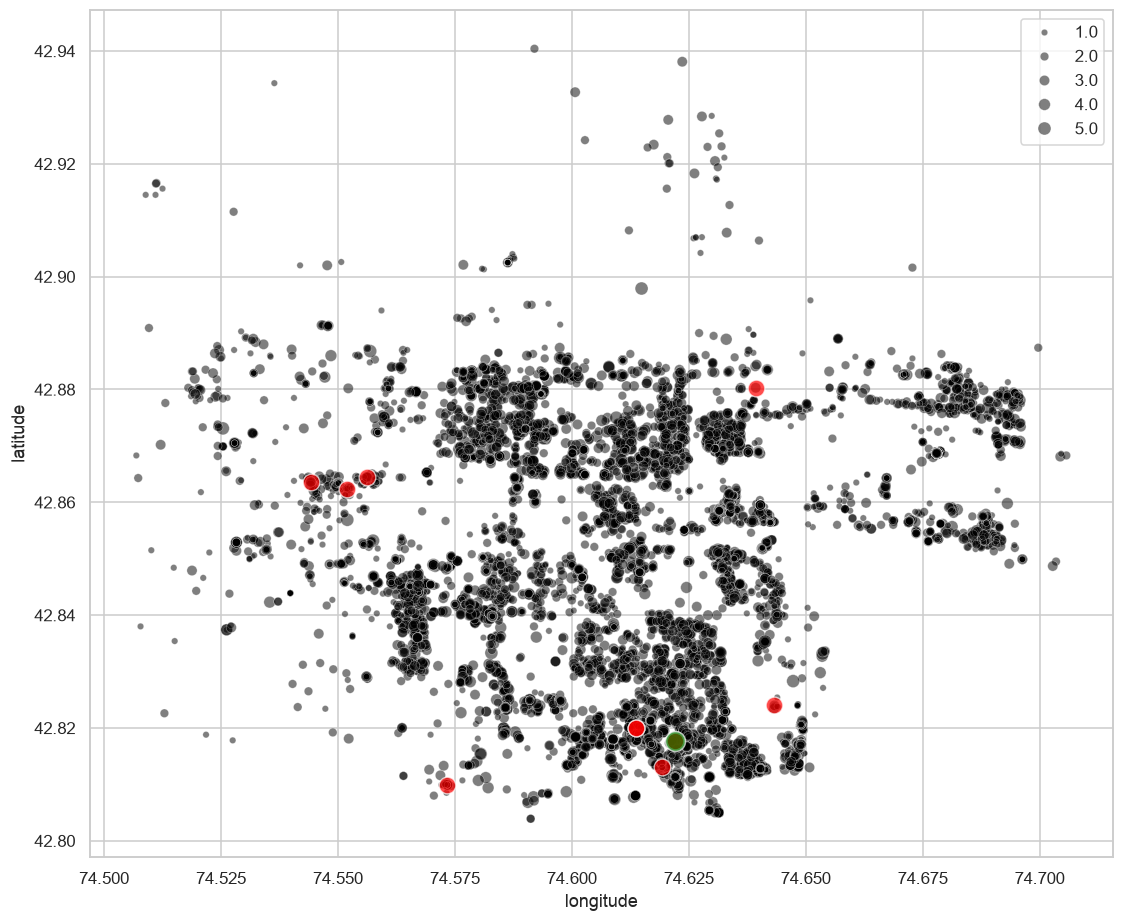

In [115]:
plt.subplots(figsize=(12, 10))
sns.scatterplot(data=work, y='latitude', x='longitude', color='black', alpha=.5, size='rooms_n')
sns.scatterplot(data=top_10_zero, y='latitude', x='longitude', color='red', alpha=.7, s=120)
sns.scatterplot(y=[top_10_zero.iloc[0].latitude], x=[top_10_zero.iloc[0].longitude], color='green', alpha=.7, s=170)

# KNN + coords

In [ ]:
def knn(data: pd.DataFrame, anchor_ind: int, featules: list, top_nn: int=10, do_normalize: bool=True ):

    X = data[featules].to_numpy()
    anchor = X[anchor_ind]
    if do_normalize:
        glob_mean = X.mean(axis=0)
        glob_std = X.std(axis=0)
        X = (X - glob_mean) / glob_std
        anchor = (anchor - glob_mean) / glob_std

    eucl_dist = np.linalg.norm(X - anchor, axis=1, )
    top_10_ind = np.argsort(eucl_dist)[:top_nn]
    return data.iloc[top_10_ind]

In [124]:
work.columns

Index(['id', 'house_kg_id', 'title', 'address', 'price_usd', 'price_kgs', 'area_m2', 'rooms_n', 'views', 'condition', 'building_series', 'floor', 'latitude',
       'longitude', 'posted_date'],
      dtype='str')

In [135]:
col_list = ['price_usd', 'area_m2', 'rooms_n', 'latitude', 'longitude']
top_10 = knn(work, 234, col_list)

<Axes: xlabel='longitude', ylabel='latitude'>

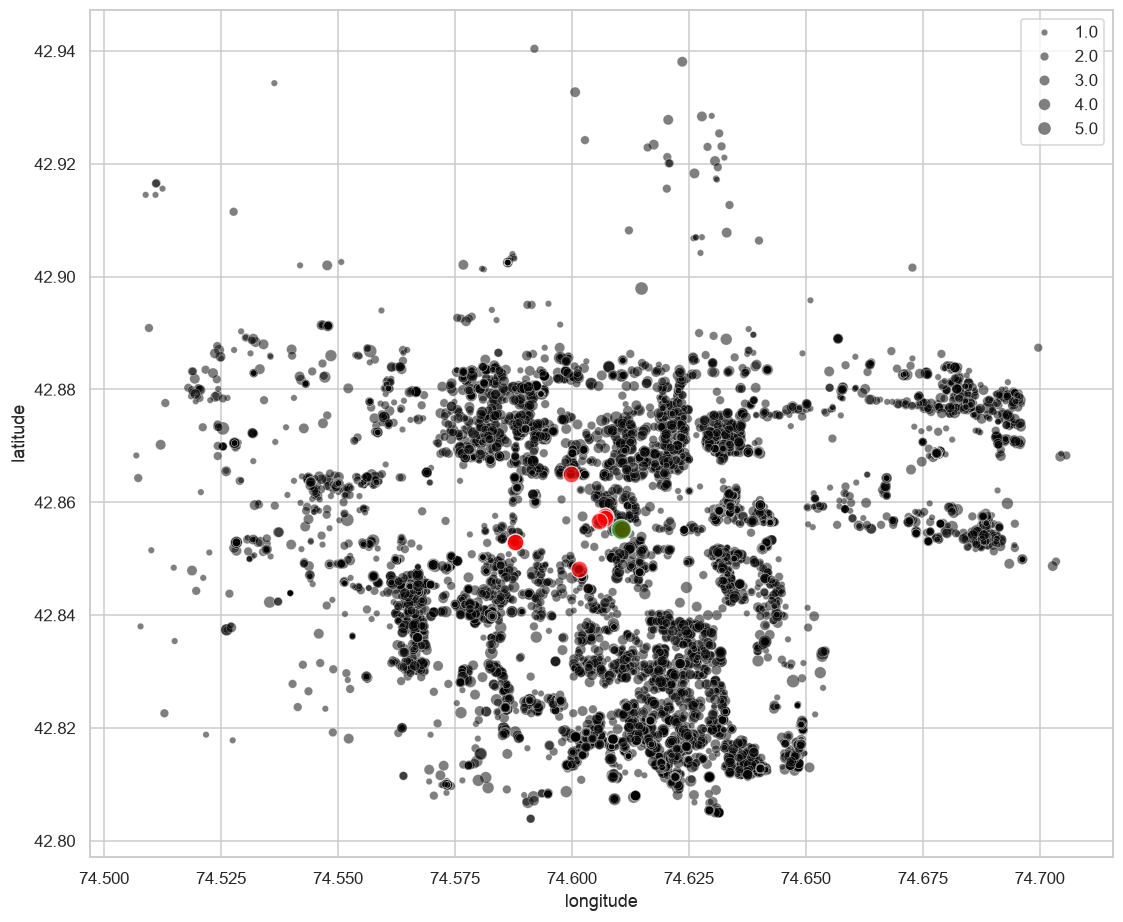

In [136]:
plt.subplots(figsize=(12, 10))
sns.scatterplot(data=work, y='latitude', x='longitude', color='black', alpha=.5, size='rooms_n')
sns.scatterplot(data=top_10, y='latitude', x='longitude', color='red', alpha=.7, s=120)
sns.scatterplot(y=[top_10.iloc[0].latitude], x=[top_10.iloc[0].longitude], color='green', alpha=.7, s=170)

# FLOOR SEARCH

In [141]:
work.dropna(subset=['floor'], inplace=True)

In [184]:
work.columns

Index(['id', 'house_kg_id', 'title', 'address', 'price_usd', 'price_kgs', 'area_m2', 'rooms_n', 'views', 'condition', 'building_series', 'floor', 'latitude',
       'longitude', 'posted_date', 'num_floor', 'wt_floor', 'floor_is_first', 'floor_is_top'],
      dtype='str')

In [159]:
def get_floor(ex):
    if ('цоколь' in ex) or ('подвал' in ex):
        return -1
    else:
        return int(ex.split('этаж из')[0].strip())

def num_floor(ex):
    if ('цоколь' in ex) or ('подвал' in ex):
        return int(ex.split('из')[-1].replace('этажей', '').strip())
    else:
        return int(ex.split('этаж из')[-1].strip())

In [161]:
work['num_floor'] = work.floor.map(num_floor)
work['wt_floor'] = work.floor.map(get_floor)

In [172]:
work['floor_is_first'] = (work.wt_floor == 1).astype(int)
work['floor_is_top'] = (work.wt_floor ==work.num_floor).astype(int)

In [192]:
work['floor_is_first'].sum()
work['ppm2'] = work.price_usd / work.area_m2

In [193]:
work.groupby('floor_is_first').agg({'ppm2': 'describe'})

ppm2                                                                                    
                  count         mean         std         min          25%          50%     75%          max
floor_is_first                                                                                             
0               11419.0  1552.768283  317.571883  676.470588  1309.647560  1550.000000  1770.0  2518.181818
1                 731.0  1612.460998  287.338208  866.666667  1424.038462  1630.434783  1800.0  2500.000000

<Axes: xlabel='ppm2', ylabel='Density'>

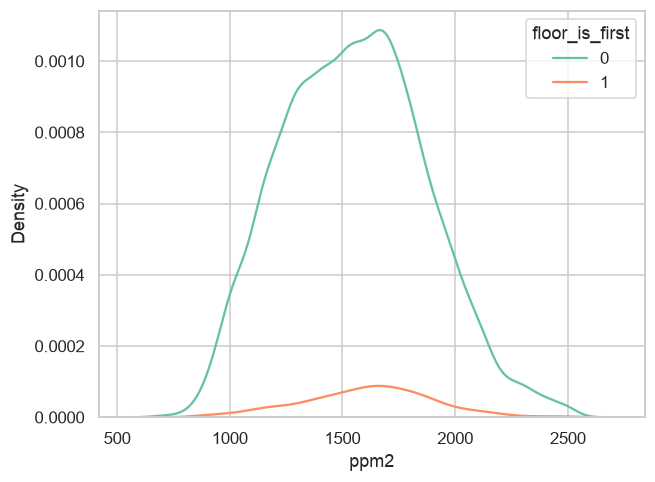

In [194]:
sns.kdeplot(data=work, x='ppm2', hue='floor_is_first', palette='Set2')

<Axes: xlabel='ppm2', ylabel='building_series'>

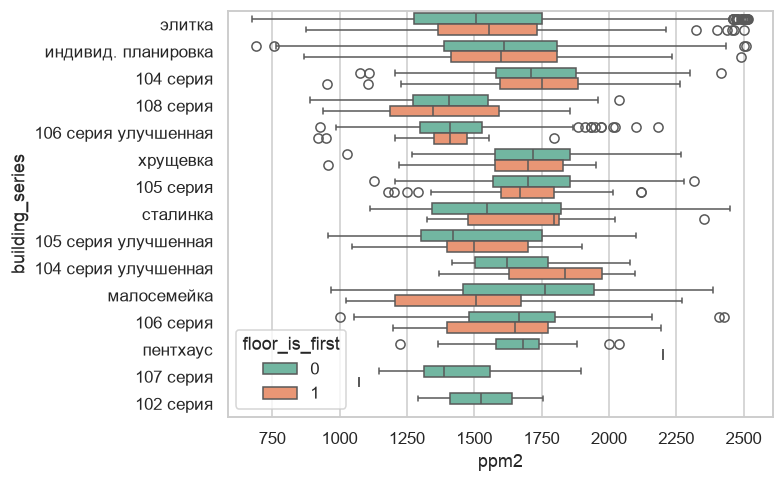

In [195]:
sns.boxplot(data=work, x='ppm2', y='building_series', palette='Set2', orient='h', hue='floor_is_first')